# Chapter 4d -- Real assets & impact investing vehicles

Translated from `HSF/4. ESG Products/*.m` (Roncalli, *Handbook of
Sustainable Finance*): `chap4_real_asset1.m` through `real_asset4.m`
(4 scripts), plus the `Data/*.m` prep scripts feeding them.

Concludes Chapter 4 (ESG Products), continuing
[`04c_the_greenium.ipynb`](04c_the_greenium.ipynb) with private-markets
sustainable investing vehicles: PRI-signatory growth, impact-fund AUM
(committed but undeployed "dry powder" vs. already-invested remaining
value), and institutional investors' real-asset allocation mix over
the past decade. All data is real, read directly via `pandas.read_excel`.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. PRI signatory growth

From `chap4_real_asset1.m`. Cumulative number of PRI (Principles for
Responsible Investment) signatories, quarterly, 2018 onward -- read
from the `PRI signatories` sheet of `chap4_real_asset1.xlsx`.

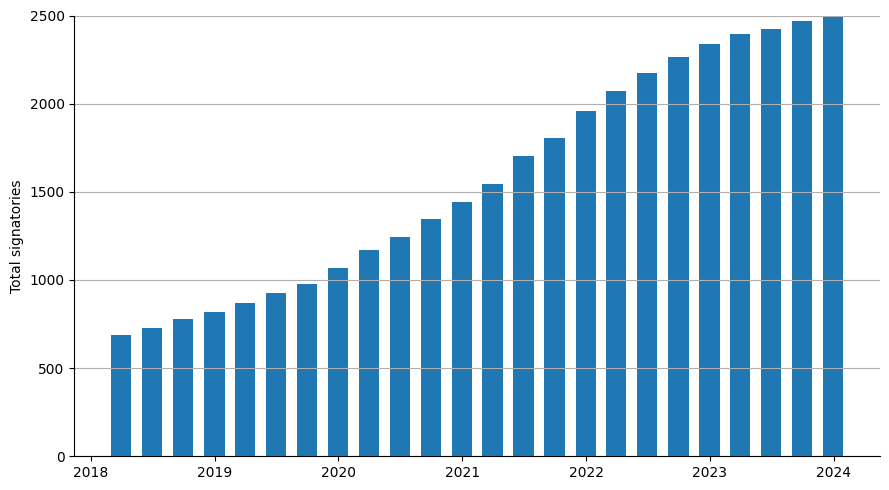

In [2]:

pri = pd.read_excel(f"{DATA_DIR}/chap4_real_asset1.xlsx", sheet_name="PRI signatories")
pri.columns = ["Date", "New signatories", "Total signatories"]
pri["Date"] = pd.to_datetime(pri["Date"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pri["Date"], pri["Total signatories"], width=60, color="tab:blue")
ax.set_ylim(0, 2500)
ax.set_ylabel("Total signatories")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


## 2. Impact fund AUM: dry powder vs. deployed capital

From `chap4_real_asset2.m`. Impact-investing AUM split between
committed-but-undeployed capital ("dry powder") and the remaining
value of already-made investments, annually -- read from the `Impact
AUM` sheet of `chap4_real_asset1.xlsx`.

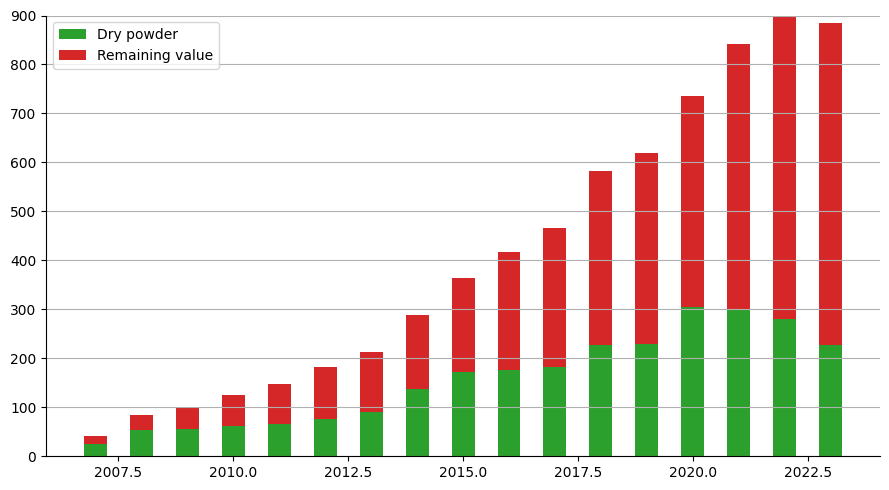

2023 total impact AUM: $885bn (26% dry powder)


In [3]:

impact_aum = pd.read_excel(f"{DATA_DIR}/chap4_real_asset1.xlsx", sheet_name="Impact AUM")
impact_aum.columns = ["Year", "Dry powder", "Remaining value", "Total"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(impact_aum["Year"], impact_aum["Dry powder"], width=0.5, color="tab:green", label="Dry powder")
ax.bar(impact_aum["Year"], impact_aum["Remaining value"], width=0.5,
       bottom=impact_aum["Dry powder"], color="tab:red", label="Remaining value")
ax.set_ylim(0, 900)
ax.legend(fontsize=10)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

print(f"2023 total impact AUM: ${impact_aum['Total'].iloc[-1]:.0f}bn "
      f"({100*impact_aum['Dry powder'].iloc[-1]/impact_aum['Total'].iloc[-1]:.0f}% dry powder)")


## 3. Institutional investors' real-asset allocation mix

Two scripts (`chap4_real_asset3.m`, `real_asset4.m`, data prepared by
`Data/chap4_real_asset2.m`) on how institutional investors have
allocated real-asset capital across private equity, private debt,
real estate, and infrastructure, 2014-2023 -- read from the
`McKinsey-2` sheet of `chap4_real_asset2.xlsx`.

### 3.1 Allocation mix over time

From `chap4_real_asset3.m`.

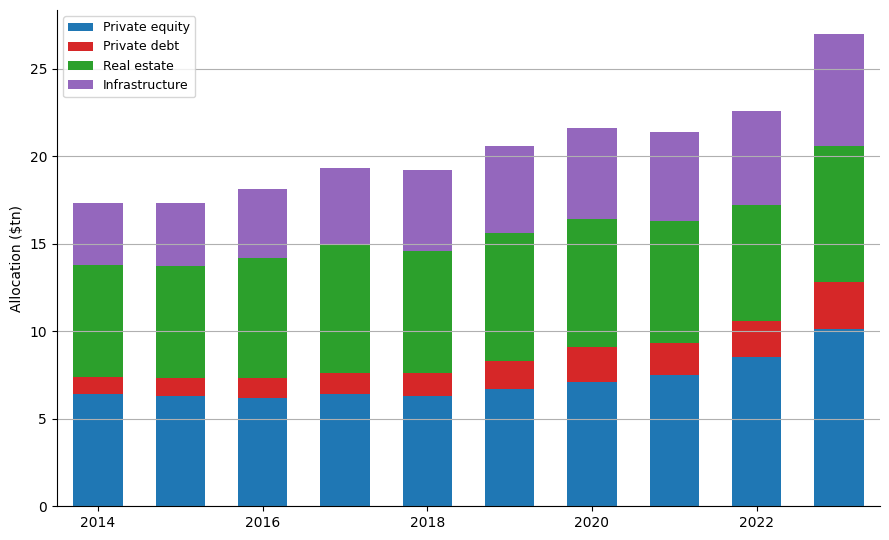

In [4]:

inst = pd.read_excel(f"{DATA_DIR}/chap4_real_asset2.xlsx", sheet_name="McKinsey-2")
inst.columns = ["Year", "Private equity", "Private debt", "Real estate", "Infrastructure", "Total"]

categories = ["Private equity", "Private debt", "Real estate", "Infrastructure"]
colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]

fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = np.zeros(len(inst))
for cat, color in zip(categories, colors):
    ax.bar(inst["Year"], inst[cat], bottom=bottom, color=color, label=cat, width=0.6)
    bottom += inst[cat].values

ax.set_xlim(2013.5, 2023.5)
ax.set_ylabel("Allocation ($tn)")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


### 3.2 Overall growth rate

From `chap4_real_asset4.m`. Total (absolute) and annualized growth of
institutional real-asset AUM, start to end of sample.

In [5]:

n_years = inst["Year"].iloc[-1] - inst["Year"].iloc[0]
total = inst[categories].sum(axis=1)
g_total = total.iloc[-1] / total.iloc[0] - 1
g_annual = (total.iloc[-1] / total.iloc[0]) ** (1 / n_years) - 1

print(f"{inst['Year'].iloc[0]}: ${total.iloc[0]:.1f}tn  ->  {inst['Year'].iloc[-1]}: ${total.iloc[-1]:.1f}tn")
print(f"Total growth: {100*g_total:.1f}%,  Annualized: {100*g_annual:.1f}%")


2014: $17.3tn  ->  2023: $27.0tn
Total growth: 56.1%,  Annualized: 5.1%
